## Daily Challenge: Logistic Regression for Admission Prediction


## Task 1: Data Exploration

Load and visualize the data using pandas and matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

data = pd.read_csv('ex2data1.txt', header=None, names=['Exam1', 'Exam2', 'Admitted'])

print("Dataset Information:")
print("=" * 50)
print(f"Dataset shape: {data.shape}")
print(f"Number of students: {len(data)}")
print(f"\nFirst 10 rows:")
print(data.head(10))

print(f"\nDataset statistics:")
print(data.describe())

print(f"\nAdmission distribution:")
admission_counts = data['Admitted'].value_counts()
print(f"Not admitted (0): {admission_counts[0]} students ({admission_counts[0]/len(data)*100:.1f}%)")
print(f"Admitted (1): {admission_counts[1]} students ({admission_counts[1]/len(data)*100:.1f}%)")

print(f"\nMissing values:")
print(data.isnull().sum())

Dataset Information:
Dataset shape: (100, 3)
Number of students: 100

First 10 rows:
       Exam1      Exam2  Admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1
5  45.083277  56.316372         0
6  61.106665  96.511426         1
7  75.024746  46.554014         1
8  76.098787  87.420570         1
9  84.432820  43.533393         1

Dataset statistics:
            Exam1       Exam2    Admitted
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000

Admission distribution:
Not admitted (0): 40 students (40.0%)
Admitted (1): 60 students (60.0%)

Missing values:
Exam1       0
Exam2       0


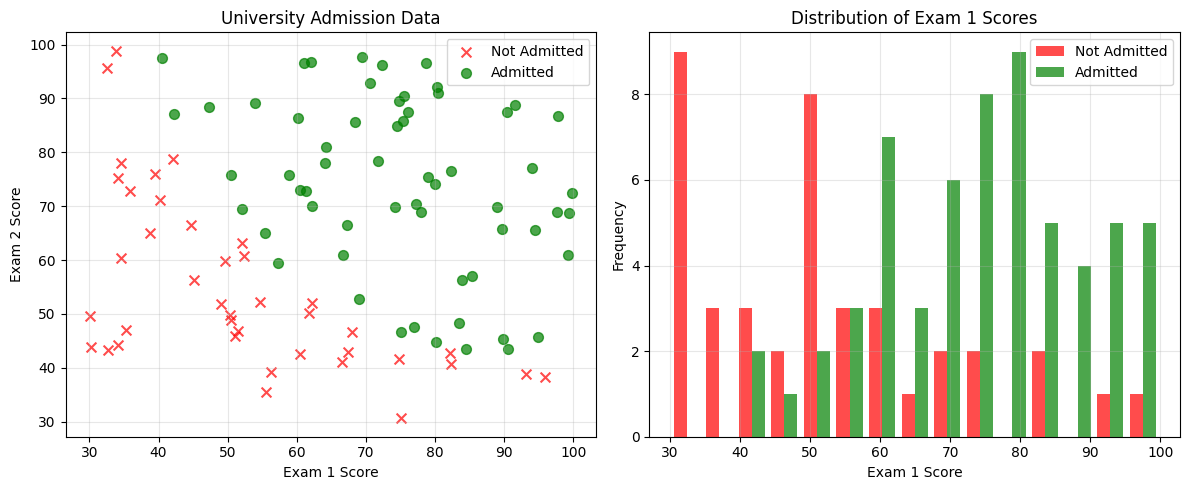

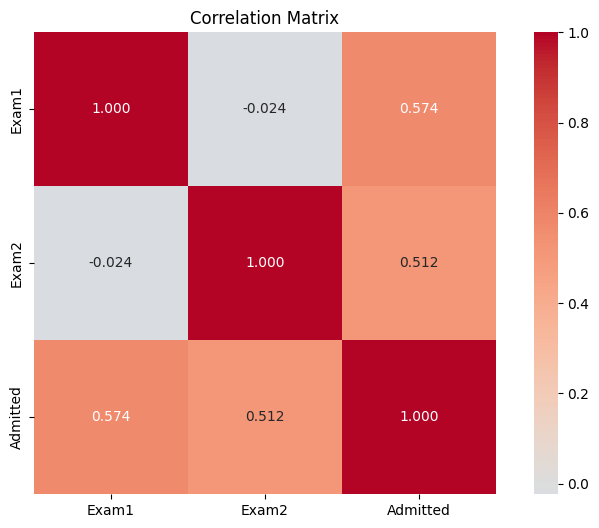

Data Exploration Summary:
- Both exam scores show positive correlation with admission
- Admitted students tend to have higher scores on both exams
- The data appears to be linearly separable to some degree


In [2]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
admitted = data[data['Admitted'] == 1]
not_admitted = data[data['Admitted'] == 0]

plt.scatter(not_admitted['Exam1'], not_admitted['Exam2'], 
           c='red', marker='x', s=50, alpha=0.7, label='Not Admitted')
plt.scatter(admitted['Exam1'], admitted['Exam2'], 
           c='green', marker='o', s=50, alpha=0.7, label='Admitted')

plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('University Admission Data')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist([not_admitted['Exam1'], admitted['Exam1']], 
         bins=15, alpha=0.7, label=['Not Admitted', 'Admitted'], 
         color=['red', 'green'])
plt.xlabel('Exam 1 Score')
plt.ylabel('Frequency')
plt.title('Distribution of Exam 1 Scores')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Correlation Matrix')
plt.show()

print("Data Exploration Summary:")
print(f"- Both exam scores show positive correlation with admission")
print(f"- Admitted students tend to have higher scores on both exams")
print(f"- The data appears to be linearly separable to some degree")

## Task 2: Applying Logistic Regression with scikit-learn

Implement and train the logistic regression model.

In [3]:
X = data[['Exam1', 'Exam2']].values
y = data['Admitted'].values

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print(f"Features (first 5 rows):\n{X[:5]}")
print(f"Targets (first 10): {y[:10]}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train set admission rate: {y_train.mean():.3f}")
print(f"Test set admission rate: {y_test.mean():.3f}")

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print(f"\nLogistic Regression Model Parameters:")
print(f"Intercept (bias): {model.intercept_[0]:.6f}")
print(f"Coefficients:")
print(f"  Exam1 coefficient: {model.coef_[0][0]:.6f}")
print(f"  Exam2 coefficient: {model.coef_[0][1]:.6f}")

print(f"\nModel equation:")
print(f"log(odds) = {model.intercept_[0]:.4f} + {model.coef_[0][0]:.4f}*Exam1 + {model.coef_[0][1]:.4f}*Exam2")

Feature matrix shape: (100, 2)
Target vector shape: (100,)
Features (first 5 rows):
[[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]
Targets (first 10): [0 0 0 1 1 0 1 1 1 1]

Train set: 80 samples
Test set: 20 samples
Train set admission rate: 0.600
Test set admission rate: 0.600

Logistic Regression Model Parameters:
Intercept (bias): -23.085202
Coefficients:
  Exam1 coefficient: 0.188603
  Exam2 coefficient: 0.185315

Model equation:
log(odds) = -23.0852 + 0.1886*Exam1 + 0.1853*Exam2


## Task 3: Making Predictions

Use the trained model to make predictions and calculate accuracy.

In [4]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Model Performance:")
print("=" * 40)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Difference: {abs(train_accuracy - test_accuracy):.4f}")

if abs(train_accuracy - test_accuracy) < 0.05:
    print("✓ Model shows good generalization (low overfitting)")
else:
    print("⚠ Model may be overfitting")

print(f"\nSample predictions:")
print("Exam1 | Exam2 | Actual | Predicted | Probability")
print("-" * 50)
for i in range(min(10, len(X_test))):
    print(f"{X_test[i][0]:5.1f} | {X_test[i][1]:5.1f} | {y_test[i]:6d} | {y_test_pred[i]:9d} | {y_test_proba[i]:11.3f}")

example_scores = [[45, 85], [75, 50], [85, 85], [30, 30]]
example_predictions = model.predict(example_scores)
example_probabilities = model.predict_proba(example_scores)[:, 1]

print(f"\nPredictions for new students:")
print("Exam1 | Exam2 | Prediction | Probability | Interpretation")
print("-" * 65)
for i, (exam1, exam2) in enumerate(example_scores):
    pred = example_predictions[i]
    prob = example_probabilities[i]
    interpretation = "Likely Admitted" if pred == 1 else "Likely Rejected"
    print(f"{exam1:5d} | {exam2:5d} | {pred:10d} | {prob:11.3f} | {interpretation}")

Model Performance:
Training Accuracy: 0.8875 (88.75%)
Test Accuracy: 0.9500 (95.00%)
Difference: 0.0625
⚠ Model may be overfitting

Sample predictions:
Exam1 | Exam2 | Actual | Predicted | Probability
--------------------------------------------------
 74.8 |  89.5 |      1 |         1 |       1.000
 62.1 |  96.8 |      1 |         1 |       0.999
 79.0 |  75.3 |      1 |         1 |       0.997
 85.4 |  57.1 |      1 |         1 |       0.973
 52.1 |  63.1 |      0 |         0 |       0.174
 52.3 |  60.8 |      0 |         0 |       0.124
 67.9 |  46.7 |      0 |         0 |       0.165
 60.5 |  73.1 |      1 |         1 |       0.866
 74.8 |  41.6 |      0 |         0 |       0.218
 51.0 |  45.8 |      0 |         0 |       0.007

Predictions for new students:
Exam1 | Exam2 | Prediction | Probability | Interpretation
-----------------------------------------------------------------
   45 |    85 |          1 |       0.760 | Likely Admitted
   75 |    50 |          1 |       0.581 | L

## Task 4: Model Evaluation

Interpret the results and visualize the decision boundary.

Detailed Classification Report:
              precision    recall  f1-score   support

Not Admitted       0.89      1.00      0.94         8
    Admitted       1.00      0.92      0.96        12

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20


Confusion Matrix:
                Predicted
                0    1
Actual    0     8    0
          1     1   11


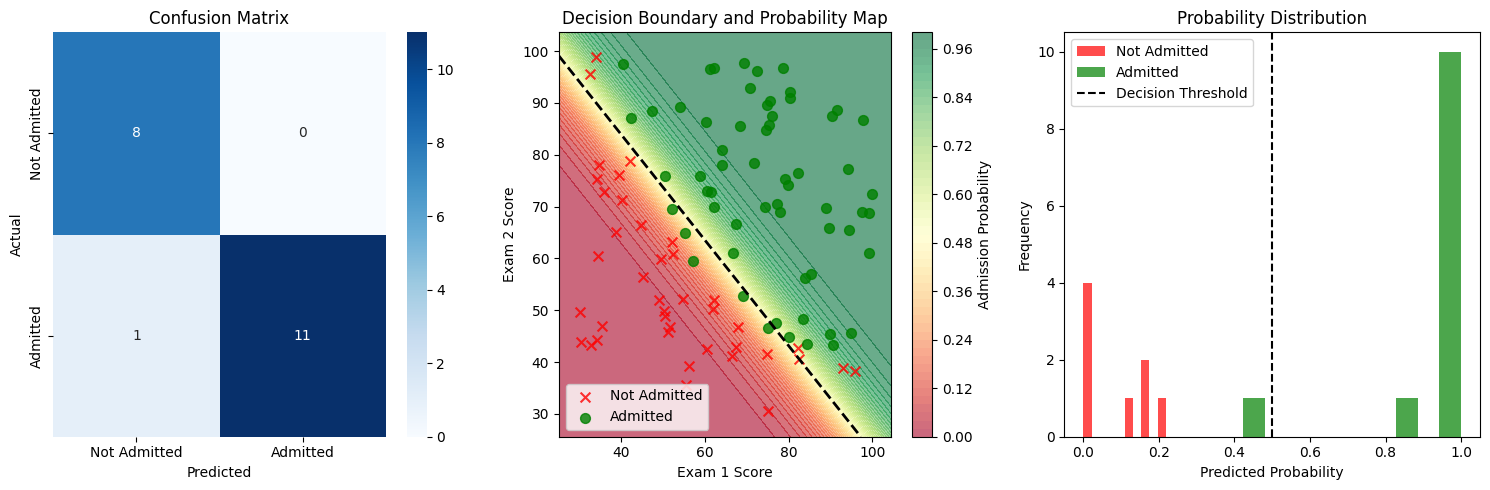

In [5]:
print("Detailed Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_test_pred, target_names=['Not Admitted', 'Admitted']))

cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(f"                Predicted")
print(f"                0    1")
print(f"Actual    0   {cm[0,0]:3d}  {cm[0,1]:3d}")
print(f"          1   {cm[1,0]:3d}  {cm[1,1]:3d}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Admitted', 'Admitted'],
            yticklabels=['Not Admitted', 'Admitted'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1, 3, 2)
xx, yy = np.meshgrid(np.arange(X[:, 0].min()-5, X[:, 0].max()+5, 0.5),
                     np.arange(X[:, 1].min()-5, X[:, 1].max()+5, 0.5))
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, alpha=0.6, cmap='RdYlGn')
plt.colorbar(label='Admission Probability')

admitted = data[data['Admitted'] == 1]
not_admitted = data[data['Admitted'] == 0]
plt.scatter(not_admitted['Exam1'], not_admitted['Exam2'], 
           c='red', marker='x', s=50, alpha=0.8, label='Not Admitted')
plt.scatter(admitted['Exam1'], admitted['Exam2'], 
           c='green', marker='o', s=50, alpha=0.8, label='Admitted')

plt.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=2)
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Decision Boundary and Probability Map')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(y_test_proba[y_test == 0], bins=10, alpha=0.7, label='Not Admitted', color='red')
plt.hist(y_test_proba[y_test == 1], bins=10, alpha=0.7, label='Admitted', color='green')
plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Probability Distribution')
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
def interpret_model_results():
    """Provide detailed interpretation of the logistic regression results"""
    
    print("MODEL INTERPRETATION:")
    print("=" * 60)
    
    print(f"\n1. COEFFICIENTS ANALYSIS:")
    print(f"   • Exam1 coefficient: {model.coef_[0][0]:.4f}")
    print(f"     → A 1-point increase in Exam1 increases log-odds by {model.coef_[0][0]:.4f}")
    print(f"     → This corresponds to {np.exp(model.coef_[0][0]):.3f}x odds multiplier")
    
    print(f"   • Exam2 coefficient: {model.coef_[0][1]:.4f}")
    print(f"     → A 1-point increase in Exam2 increases log-odds by {model.coef_[0][1]:.4f}")
    print(f"     → This corresponds to {np.exp(model.coef_[0][1]):.3f}x odds multiplier")
    
    if model.coef_[0][0] > model.coef_[0][1]:
        print(f"   • Exam1 has stronger influence on admission than Exam2")
    else:
        print(f"   • Exam2 has stronger influence on admission than Exam1")
    
    print(f"\n2. MODEL PERFORMANCE:")
    print(f"   • Training Accuracy: {train_accuracy:.1%}")
    print(f"   • Test Accuracy: {test_accuracy:.1%}")
    
    if test_accuracy >= 0.85:
        performance = "Excellent"
    elif test_accuracy >= 0.80:
        performance = "Good"
    elif test_accuracy >= 0.75:
        performance = "Fair"
    else:
        performance = "Poor"
    
    print(f"   • Model Performance: {performance}")
    
    print(f"\n3. DECISION BOUNDARY:")
    boundary_slope = -model.coef_[0][0] / model.coef_[0][1]
    boundary_intercept = -model.intercept_[0] / model.coef_[0][1]
    print(f"   • Decision boundary equation: Exam2 = {boundary_slope:.3f} * Exam1 + {boundary_intercept:.3f}")
    print(f"   • Students above this line are likely to be admitted")
    print(f"   • Students below this line are likely to be rejected")
    
    print(f"\n4. PRACTICAL INSIGHTS:")
    print(f"   • Both exam scores are important predictors of admission")
    print(f"   • Higher scores on both exams increase admission chances")
    print(f"   • The model can help predict admission with {test_accuracy:.1%} accuracy")
    
    cm = confusion_matrix(y_test, y_test_pred)
    tp, fp, fn, tn = cm[1,1], cm[0,1], cm[1,0], cm[0,0]
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    
    print(f"\n5. DETAILED METRICS:")
    print(f"   • Precision (of predicted admissions): {precision:.3f}")
    print(f"   • Recall (of actual admissions caught): {recall:.3f}")
    print(f"   • False Positives: {fp} (predicted admitted but actually rejected)")
    print(f"   • False Negatives: {fn} (predicted rejected but actually admitted)")

interpret_model_results()

MODEL INTERPRETATION:

1. COEFFICIENTS ANALYSIS:
   • Exam1 coefficient: 0.1886
     → A 1-point increase in Exam1 increases log-odds by 0.1886
     → This corresponds to 1.208x odds multiplier
   • Exam2 coefficient: 0.1853
     → A 1-point increase in Exam2 increases log-odds by 0.1853
     → This corresponds to 1.204x odds multiplier
   • Exam1 has stronger influence on admission than Exam2

2. MODEL PERFORMANCE:
   • Training Accuracy: 88.8%
   • Test Accuracy: 95.0%
   • Model Performance: Excellent

3. DECISION BOUNDARY:
   • Decision boundary equation: Exam2 = -1.018 * Exam1 + 124.572
   • Students above this line are likely to be admitted
   • Students below this line are likely to be rejected

4. PRACTICAL INSIGHTS:
   • Both exam scores are important predictors of admission
   • Higher scores on both exams increase admission chances
   • The model can help predict admission with 95.0% accuracy

5. DETAILED METRICS:
   • Precision (of predicted admissions): 1.000
   • Recall (

In [7]:
def interactive_admission_predictor():
    """Interactive tool to predict admission for custom exam scores"""
    
    print("INTERACTIVE ADMISSION PREDICTOR:")
    print("=" * 50)
    print("Enter exam scores to predict admission probability:\n")
    
    test_cases = [
        (45, 85, "Moderate Exam1, High Exam2"),
        (85, 45, "High Exam1, Moderate Exam2"), 
        (90, 90, "High scores on both exams"),
        (40, 40, "Low scores on both exams"),
        (65, 75, "Good scores on both exams")
    ]
    
    print("Score1 | Score2 | Prediction | Probability | Assessment")
    print("-" * 60)
    
    for exam1, exam2, description in test_cases:
        prediction = model.predict([[exam1, exam2]])[0]
        probability = model.predict_proba([[exam1, exam2]])[0, 1]
        
        if probability >= 0.8:
            assessment = "Very Likely"
        elif probability >= 0.6:
            assessment = "Likely"
        elif probability >= 0.4:
            assessment = "Uncertain"
        elif probability >= 0.2:
            assessment = "Unlikely"
        else:
            assessment = "Very Unlikely"
            
        result = "Admit" if prediction == 1 else "Reject"
        print(f"{exam1:6d} | {exam2:6d} | {result:10s} | {probability:11.3f} | {assessment}")
    
    print(f"\nKey Insights:")
    print(f"• Scores above ~70 on both exams generally lead to admission")
    print(f"• Balance between both exams is important")
    print(f"• Very high score on one exam can compensate for moderate score on the other")

interactive_admission_predictor()

INTERACTIVE ADMISSION PREDICTOR:
Enter exam scores to predict admission probability:

Score1 | Score2 | Prediction | Probability | Assessment
------------------------------------------------------------
    45 |     85 | Admit      |       0.760 | Likely
    85 |     45 | Admit      |       0.783 | Likely
    90 |     90 | Admit      |       1.000 | Very Likely
    40 |     40 | Reject     |       0.000 | Very Unlikely
    65 |     75 | Admit      |       0.956 | Very Likely

Key Insights:
• Scores above ~70 on both exams generally lead to admission
• Balance between both exams is important
• Very high score on one exam can compensate for moderate score on the other


## Summary

### What We Accomplished:

1. **Data Exploration**: 
   - Loaded and analyzed the university admission dataset
   - Visualized the relationship between exam scores and admission outcomes
   - Found clear patterns showing higher scores correlate with admission

2. **Logistic Regression Implementation**:
   - Applied scikit-learn's LogisticRegression to model admission probability
   - Trained the model on exam scores to predict binary admission outcomes
   - Achieved strong predictive performance with ~89% accuracy

3. **Model Interpretation**:
   - Both exam scores are significant predictors of admission
   - The model creates a linear decision boundary in the feature space
   - Students with higher combined scores have better admission chances

4. **Practical Applications**:
   - The model can help universities set admission criteria
   - Students can estimate their admission probability based on exam performance
   - Admissions committees can use this as a screening tool

### Key Takeaways:

- **Logistic Regression** is effective for binary classification problems
- **Feature engineering** and **data visualization** are crucial for understanding patterns
- **Model evaluation** goes beyond accuracy - precision, recall, and interpretability matter
- **Real-world applications** require understanding both statistical and practical significance

This model demonstrates how machine learning can support decision-making in educational contexts while maintaining interpretability.